Loading data from: /mnt/g/mp/Decoding-Au-clusters/dimredpy_vs_others/subset_10000.txt
Data shape: (5000, 13)
Number of Landmarks: 100

          RUNNING REFERENCE FRAMEWORK (sketchmap_cpp)
-> Reference execution finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy execution finished.

          PARITY VALIDATION
1. Indices Match Exact: True
2. Voronoi Weights MSE: 1.264949e-36

SUCCESS: DimRedPy Landmark Selection is mathematically perfect.


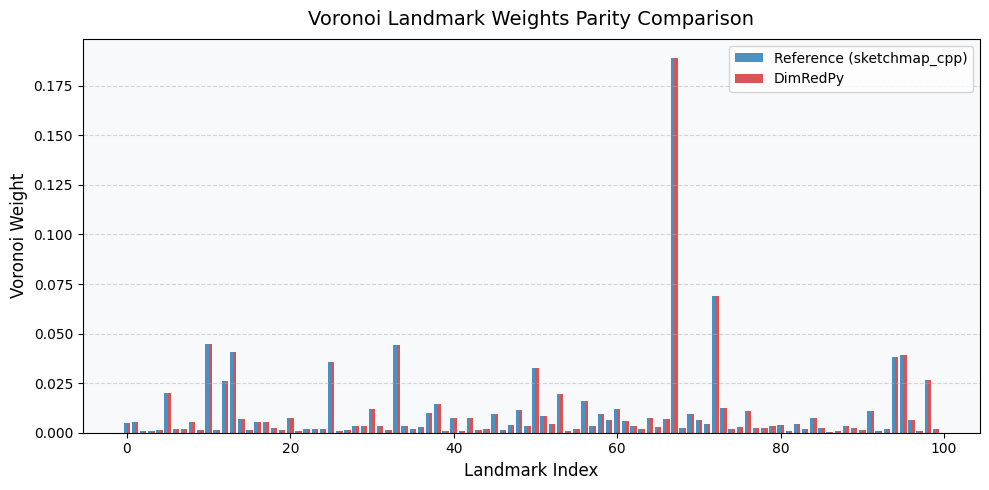

Saved comparison plot to /mnt/g/mp/Decoding-Au-clusters/verify_parity_sketchmap_selection_plot.png


In [1]:
"""
Rigorous Verification of Sketch-map Landmark Selection (DimRedPy vs sketchmap_cpp)

This script validates that the DimRedPy framework produces mathematically identical results
to the underlying legacy C++ sketchmap implementation. We utilize rigorous statistical metrics:
1. Indices Match Exact (Compares selected landmark indices)
2. Voronoi Weights MSE (Compares computed weights for landmarks)
"""

import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import sketchmap_cpp as smap
from dimredpy.sketchmap import select_landmarks

# ---------------------------------------------------------------------------
# 1. Load the Dataset
# ---------------------------------------------------------------------------
candidate_paths = [
    os.path.join(script_dir, "..", "subset_10000.txt"),
    os.path.join(os.getcwd(), "subset_10000.txt"),
    os.path.join(os.getcwd(), "dimredpy_vs_others", "subset_10000.txt")
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find subset_10000.txt in any expected location.")

print(f"Loading data from: {data_path}")
data = np.loadtxt(data_path, max_rows=5000)
n_landmarks = 100
print(f"Data shape: {data.shape}")
print(f"Number of Landmarks: {n_landmarks}")

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (sketchmap_cpp)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (sketchmap_cpp)")
print("=======================================================")
ref_res = smap.select_landmarks(
    data, 
    n_landmarks=n_landmarks, 
    mode="minmax", 
    seed=42, 
    first=0,
    unique=True,
    return_weights=True
)
ref_indices = ref_res["indices"]
ref_weights = ref_res["weights"]
print("-> Reference execution finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")
py_res = select_landmarks(
    data, 
    n_landmarks=n_landmarks, 
    mode="minmax", 
    seed=42, 
    first=0,
    unique=True,
    return_weights=True
)
py_indices = py_res["indices"]
py_weights = py_res["weights"]
print("-> DimRedPy execution finished.")

# ---------------------------------------------------------------------------
# 4. Rigorous Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

indices_match = np.array_equal(ref_indices, py_indices)
weights_mse = np.mean((ref_weights - py_weights)**2)

print(f"1. Indices Match Exact: {indices_match}")
print(f"2. Voronoi Weights MSE: {weights_mse:.6e}")

if indices_match and weights_mse < 1e-10:
    print("\nSUCCESS: DimRedPy Landmark Selection is mathematically perfect.")
else:
    print("\nFAILURE: Statistical divergence detected in Selection.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 5), facecolor='white')

# Bar width
width = 0.4
x = np.arange(n_landmarks)

axes.bar(x - width/2, ref_weights, width, label='Reference (sketchmap_cpp)', color='#1f77b4', alpha=0.8)
axes.bar(x + width/2, py_weights, width, label='DimRedPy', color='#d62728', alpha=0.8)

axes.set_title("Voronoi Landmark Weights Parity Comparison", fontsize=14, pad=10)
axes.set_xlabel("Landmark Index", fontsize=12)
axes.set_ylabel("Voronoi Weight", fontsize=12)
axes.legend(fontsize=10)
axes.grid(True, linestyle='--', alpha=0.5, axis='y')
axes.set_facecolor('#f8f9fa')

plt.tight_layout()

plot_path = os.path.join(script_dir, "verify_parity_sketchmap_selection_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved comparison plot to {plot_path}")
